In [14]:
import pandas as pd
from graphviz import Digraph
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.figure_factory as ff
import plotly.offline as py

# Load dataset
### NHANES 2017-March 2020 Pre-pandemic
https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2017-2020 \
The NHANES program suspended field operations in March 2020 due to the coronavirus disease 2019 (COVID-19) pandemic.

# List of attributes
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.htm
  * **RIDAGEYR**: Age in years, at the time of the screening interview
  * **RIAGENDR**: Gender of the participant
      * Code: 1: Male; 2: Female, .: Missing
  * **RIDRETH3**: Recode of reported race and Hispanic origin information, with Non-Hispanic Asian Category
      * Code:
  * **DMDEDUC2**: Education level - Adults 20+
  * **INDFMPIR**: Ratio of family income to poverty
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.htm
    * **BMXBMI**: Body Mass Index (kg/m**2)
    * **BMXWAIST**: Waist Circumference (cm)
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_ALQ.htm
    * **ALQ111**: Ever had a drink of any kind of alcohol
    * **ALQ130**: Avg # alcoholic drinks/day - past 12 mos
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.htm
    * **BPQ020**: Ever told you had high blood pressure
    * **BPQ050A**: Now taking prescribed medicine for HBP
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.htm
    * **DIQ010**: Doctor told you have diabetes
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_SMQ.htm
    * **SMQ020**: Smoked at least 100 cigarettes in life
    * **SMQ040**: {Do you/Does SP} now smoke cigarettes?
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_PAQ.htm
    * **PAQ605**: Vigorous work activity
    * **PAQ620**: Moderate work activity

* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GLU.htm
    * ***LBXGLU***: Fasting Glucose (mg/dL)

* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_INS.htm
    * **LBXIN**: Insulin (μU/mL)

* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GHB.htm
    * **LBXGH**: HbA1c (Glycohemoglobin (%))


In [3]:
demo = pd.read_sas("./dataset/P_DEMO.xpt")
bmx = pd.read_sas("./dataset/P_BMX.xpt")
alq = pd.read_sas("./dataset/P_ALQ.xpt")
bpq = pd.read_sas("./dataset/P_BPQ.xpt")
diq = pd.read_sas("./dataset/P_DIQ.xpt")
smq = pd.read_sas("./dataset/P_SMQ.xpt")
paq = pd.read_sas("./dataset/P_PAQ.xpt")
glu = pd.read_sas("./dataset/P_GLU.xpt")
ins = pd.read_sas("./dataset/P_INS.xpt")
ghb = pd.read_sas("./dataset/P_GHB.xpt")

In [4]:
demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "DMDEDUC2", "INDFMPIR"]
bmx_cols = ["SEQN", "BMXBMI", "BMXWAIST"]
alq_cols = ["SEQN", "ALQ111", "ALQ130"]
bpq_cols = ["SEQN", "BPQ020", "BPQ050A"]
diq_cols = ["SEQN", "DIQ010"]
smq_cols = ["SEQN", "SMQ020", "SMQ040"]
paq_cols = ["SEQN", "PAQ605", "PAQ620"]
glu_cols = ["SEQN", "LBXGLU"]
ins_cols = ["SEQN", "LBXIN"]
ghb_cols = ["SEQN", "LBXGH"]

demo_sel = demo[demo_cols]
bmx_sel = bmx[bmx_cols]
alq_sel = alq[alq_cols]
bpq_sel = bpq[bpq_cols]
diq_sel = diq[diq_cols]
smq_sel = smq[smq_cols]
paq_sel = paq[paq_cols]
glu_sel = glu[glu_cols]
ins_sel = ins[ins_cols]
ghb_sel = ghb[ghb_cols]

In [5]:
merged = demo_sel.merge(bmx_sel, on="SEQN", how="inner")
merged = merged.merge(alq_sel, on="SEQN", how="inner")
merged = merged.merge(bpq_sel, on="SEQN", how="inner")
merged = merged.merge(diq_sel, on="SEQN", how="inner")
merged = merged.merge(smq_sel, on="SEQN", how="inner")
merged = merged.merge(paq_sel, on="SEQN", how="inner")
merged = merged.merge(glu_sel, on="SEQN", how="inner")
merged = merged.merge(ins_sel, on="SEQN", how="inner")
merged = merged.merge(ghb_sel, on="SEQN", how="inner")
data = merged

### Explore structure of the dataset

In [6]:
data.head()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,ALQ111,ALQ130,BPQ020,BPQ050A,DIQ010,SMQ020,SMQ040,PAQ605,PAQ620,LBXGLU,LBXIN,LBXGH
0,109271.0,49.0,1.0,3.0,2.0,NaN,29.7,120.4,1.0,NaN,2.0,NaN,2.0,1.0,1.0,2.0,1.0,103.0,16.96,5.6
1,109274.0,68.0,1.0,7.0,4.0,1.20,30.2,109.6,1.0,2.0,1.0,1.0,1.0,2.0,NaN,1.0,1.0,154.0,13.52,5.7
2,109282.0,76.0,1.0,3.0,5.0,3.61,26.6,NaN,1.0,NaN,1.0,1.0,2.0,1.0,3.0,2.0,2.0,95.0,7.49,5.5
3,109286.0,33.0,2.0,6.0,5.0,1.36,28.9,NaN,NaN,NaN,2.0,NaN,2.0,2.0,NaN,2.0,2.0,92.0,16.46,5.7
4,109290.0,68.0,2.0,4.0,5.0,5.00,28.1,92.0,1.0,NaN,1.0,1.0,1.0,2.0,NaN,2.0,1.0,106.0,20.25,8.4


In [7]:
data.describe()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,ALQ111,ALQ130,BPQ020,BPQ050A,DIQ010,SMQ020,SMQ040,PAQ605,PAQ620,LBXGLU,LBXIN,LBXGH
count,4438.00000,4438.000000,4438.000000,4438.000000,4252.000000,3.808000e+03,4348.000000,4201.000000,4165.000000,2906.000000,4438.000000,1529.000000,4438.000000,4438.000000,1828.000000,4438.000000,4438.000000,4173.000000,4079.000000,4204.000000
mean,117186.32064,49.629338,1.518026,3.495268,3.527752,2.555622e+00,29.812626,100.174387,1.097479,3.556091,1.630239,1.155657,1.876070,1.592384,2.222101,1.754845,1.575710,112.913012,15.031954,5.851308
std,4498.47671,18.292069,0.499731,1.606655,1.212897,1.615405e+00,7.720594,17.473019,0.296645,32.071829,0.544239,0.362649,0.438161,0.522994,0.919838,0.479292,0.542962,37.525950,23.963639,1.136493
min,109271.00000,18.000000,1.000000,1.000000,1.000000,5.397605e-79,14.900000,61.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,47.000000,0.710000,2.800000
25%,113333.25000,34.000000,1.000000,3.000000,3.000000,1.180000e+00,24.600000,87.500000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,95.000000,6.170000,5.300000
50%,117247.00000,51.000000,2.000000,3.000000,4.000000,2.190000e+00,28.500000,98.700000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,103.000000,10.010000,5.600000
75%,121077.75000,64.000000,2.000000,4.000000,4.000000,4.080000e+00,33.600000,111.200000,1.000000,3.000000,2.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,114.000000,16.565000,6.000000
max,124822.00000,80.000000,2.000000,7.000000,9.000000,5.000000e+00,92.300000,178.000000,2.000000,999.000000,9.000000,2.000000,9.000000,9.000000,3.000000,9.000000,9.000000,451.000000,512.500000,15.400000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4438 entries, 0 to 4437
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      4438 non-null   float64
 1   RIDAGEYR  4438 non-null   float64
 2   RIAGENDR  4438 non-null   float64
 3   RIDRETH3  4438 non-null   float64
 4   DMDEDUC2  4252 non-null   float64
 5   INDFMPIR  3808 non-null   float64
 6   BMXBMI    4348 non-null   float64
 7   BMXWAIST  4201 non-null   float64
 8   ALQ111    4165 non-null   float64
 9   ALQ130    2906 non-null   float64
 10  BPQ020    4438 non-null   float64
 11  BPQ050A   1529 non-null   float64
 12  DIQ010    4438 non-null   float64
 13  SMQ020    4438 non-null   float64
 14  SMQ040    1828 non-null   float64
 15  PAQ605    4438 non-null   float64
 16  PAQ620    4438 non-null   float64
 17  LBXGLU    4173 non-null   float64
 18  LBXIN     4079 non-null   float64
 19  LBXGH     4204 non-null   float64
dtypes: float64(20)
memory usage: 6

# What is diabetes?

Acccording to NIH, "Diabetes is a disease that occurs when your blood glucose, also called blood sugar, is too high. Blood glucose is your main source of energy and comes from the food you eat. Insulin, a hormone made by the pancreas, helps glucose from food get into your cells to be used for energy. Sometimes your body doesn’t make enough—or any—insulin or doesn’t use insulin well. Glucose then stays in your blood and doesn’t reach your cells.

Over time, having too much glucose in your blood can cause health problems. Although diabetes has no cure, you can take steps to manage your diabetes and stay healthy.

Sometimes people call diabetes “a touch of sugar” or “borderline diabetes.” These terms suggest that someone doesn’t really have diabetes or has a less serious case, but every case of diabetes is serious.

According to the diagnostic criteria established by the American Diabetes Association (ADA), diabetes can be identified through elevated fasting glucose (≥ 126 mg/dL), hemoglobin A1c (≥ 6.5%). In this project, we further include self-reported doctor diagnosis (DIQ010 == 1), and fasting insulin (≥ 15 μU/mL) as a marker of insulin resistance to capture individuals at early metabolic risk.

Such that, Diabetes risk was defined as 1 (at risk) if any of the following criteria were met:
- Fasting glucose (LBXGLU) ≥ 126 mg/dL
- Fasting insulin (LBXIN) ≥ 15 μU/mL
- Hemoglobin A1c (LBXGH) ≥ 6.5%
- Self-reported diabetes diagnosis (DIQ010 = 1, “Yes”)

Participants with none of these indicators were classified as no diabetes risk (0).

Participants with all of these values missing were classified as unknown (2).

In [9]:
def determine_diabetes_risk(row):
    # Missing case: all diabetes-related variables missing
    if (
        pd.isna(row['LBXGLU']) and
        pd.isna(row['LBXIN']) and
        pd.isna(row['LBXGH']) and
        pd.isna(row['DIQ010'])
    ):
        return 2  # Missing Data

    # Diabetes risk case
    if (
        (pd.notna(row['LBXGLU']) and row['LBXGLU'] >= 126) or
        (pd.notna(row['LBXIN']) and row['LBXIN'] >= 15) or
        (pd.notna(row['LBXGH']) and row['LBXGH'] >= 6.5) or
        (pd.notna(row['DIQ010']) and row['DIQ010'] == 1)
    ):
        return 1  # Diabetes Risk

    # Otherwise no risk
    return 0


# Apply function
data['diabetes_risk'] = data.apply(determine_diabetes_risk, axis=1)

# Convert to category and rename levels properly
data['diabetes_risk'] = data['diabetes_risk'].astype('category')
data['diabetes_risk'] = data['diabetes_risk'].cat.rename_categories({
    0: 'No Diabetes Risk',
    1: 'Diabetes Risk',
    2: 'Missing Data'
})

# Check counts
data['diabetes_risk'].value_counts()

diabetes_risk
No Diabetes Risk    2730
Diabetes Risk       1708
Name: count, dtype: int64

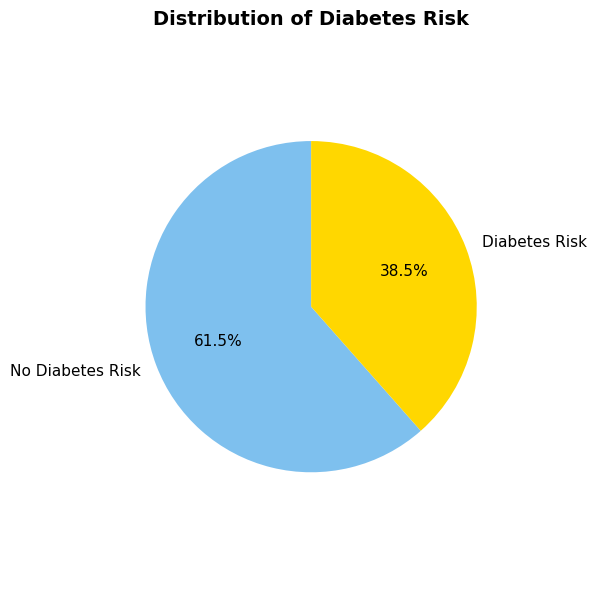

In [10]:
counts = data['diabetes_risk'].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=counts.index,            # category names
    autopct='%1.1f%%',              # show percentage
    startangle=90,                  # rotate so first slice starts at top
    colors=['#7EC0EE', '#FFD700', '#CCCCCC'],  # optional colors
    textprops={'fontsize': 11}      # font size for labels
)

# Add title
plt.title('Distribution of Diabetes Risk', fontsize=14, weight='bold')

# Equal aspect ratio ensures pie is circular
plt.axis('equal')
plt.tight_layout()
plt.show()

## Handling Missing Data

NHANES includes special nonresponse codes to represent different types of missingness across survey variables.  
The primary codes and their interpretations are as follows:

- **Code = 7 (“Refused”)** → *Missing Not at Random (MNAR)*:  
  Participants who refused to answer may differ systematically from others (e.g., individuals with sensitive or extreme values).

- **Code = 9 (“Don’t know”)** → *Missing at Random (MAR)*:  
  Missingness may depend on other observed characteristics (such as education or cognitive ability) but not directly on the true value.

- **Codes = 777 / 999 (“Missing” or “Not applicable”)** → *Likely MAR or MCAR*:  
  These typically occur due to instrument limits, data entry skips, or inapplicable survey sections.

For analytical purposes, all such nonresponse codes were **recoded to `NaN`**.  
This standardizes missing data representation across variables and allows consistent handling in subsequent analysis.

In [11]:
# DMDEDUC2: 7, 9 → NaN
data["DMDEDUC2"] = data["DMDEDUC2"].replace({7: pd.NA, 9: pd.NA})
# ALQ111: 7, 9 → NaN
data["ALQ111"] = data["ALQ111"].replace({7: pd.NA, 9: pd.NA})
# ALQ130: 777, 999 → NaN
data["ALQ130"] = data["ALQ130"].replace({777: pd.NA, 999: pd.NA})
# BPQ020: 7, 9 → NaN
data["BPQ020"] = data["BPQ020"].replace({7: pd.NA, 9: pd.NA})
# BPQ050A: 7, 9 → NaN
data["BPQ050A"] = data["BPQ050A"].replace({7: pd.NA, 9: pd.NA})
# DIQ010: 7, 9 → NaN
data["DIQ010"] = data["DIQ010"].replace({7: pd.NA, 9: pd.NA})
# SMQ020: 7, 9 → NaN
data["SMQ020"] = data["SMQ020"].replace({7: pd.NA, 9: pd.NA})
# SMQ040: 7, 9 → NaN
data["SMQ040"] = data["SMQ040"].replace({7: pd.NA, 9: pd.NA})
# PAQ605: 7, 9 → NaN
data["PAQ605"] = data["PAQ605"].replace({7: pd.NA, 9: pd.NA})
# PAQ620: 7, 9 → NaN
data["PAQ620"] = data["PAQ620"].replace({7: pd.NA, 9: pd.NA})

### Visualizing missing values

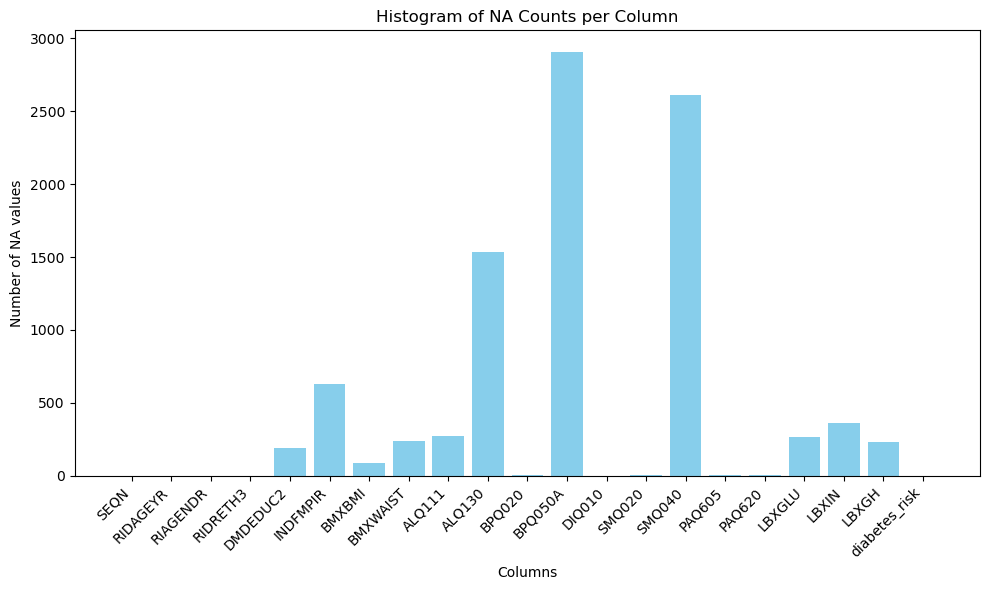

In [12]:
na_counts = data.isna().sum()
na_percent = na_counts / len(data) * 100
na_df = pd.DataFrame({'NA_Count': na_counts, 'NA_Percent': na_percent})

# Plot histogram of NA counts
plt.figure(figsize=(10, 6))
plt.bar(na_df.index, na_df['NA_Count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Columns')
plt.ylabel('Number of NA values')
plt.title('Histogram of NA Counts per Column')
plt.tight_layout()
plt.show()

In [13]:
missing_summary = pd.DataFrame({
    'NA_Count': na_counts,
    'NA_Percent': na_percent
})
missing_summary.sort_values(by='NA_Count', ascending=False)

,NA_Count,NA_Percent
BPQ050A,2909,65.547544
SMQ040,2610,58.810275
ALQ130,1535,34.587652
INDFMPIR,630,14.195584
LBXIN,359,8.089229
ALQ111,273,6.151420
LBXGLU,265,5.971158
BMXWAIST,237,5.340243
LBXGH,234,5.272645
DMDEDUC2,189,4.258675


# Temporary: Distributions

In [15]:
def plot_distribution(data_select, size_bin) :  
    # 2 datasets
    tmp1 = data[data['diabetes_risk'] == 'Diabetes Risk'][data_select].dropna()
    tmp2 = data[data['diabetes_risk'] == 'No Diabetes Risk'][data_select].dropna()
    hist_data = [tmp1, tmp2]
    
    group_labels = ['Diabetes Risk', 'No Diabetes Risk']
    colors = ['#FFD700', '#7EC0EE']

    fig = ff.create_distplot(hist_data, group_labels, colors = colors, show_hist = True, bin_size = size_bin, curve_type='kde')
    
    fig['layout'].update(title = data_select)

    py.iplot(fig, filename = 'Density plot')
 
plot_distribution('LBXGLU', 5)  # Fasting Glucose
plot_distribution('BMXBMI', 1)  # BMI
plot_distribution('BMXWAIST', 1)  # Waist Circumference
plot_distribution('LBXIN', 1)   # Insulin
plot_distribution('LBXGH', 0.2)  # HbA1c

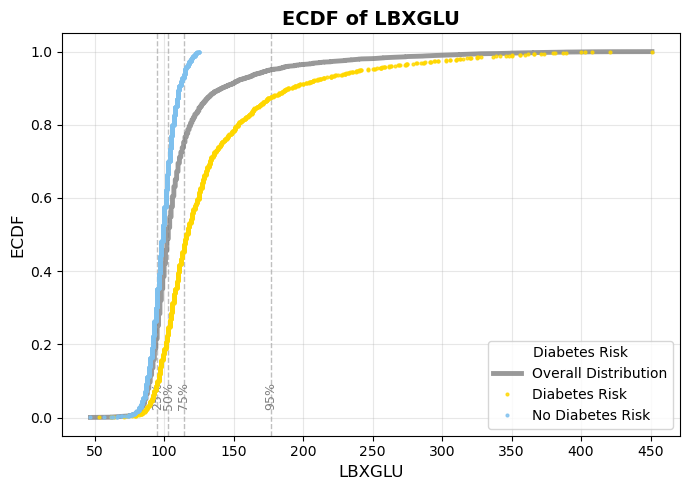


Quantiles for LBXGLU:
   25th percentile: 95.00
   50th percentile: 103.00
   75th percentile: 114.00
   95th percentile: 177.00


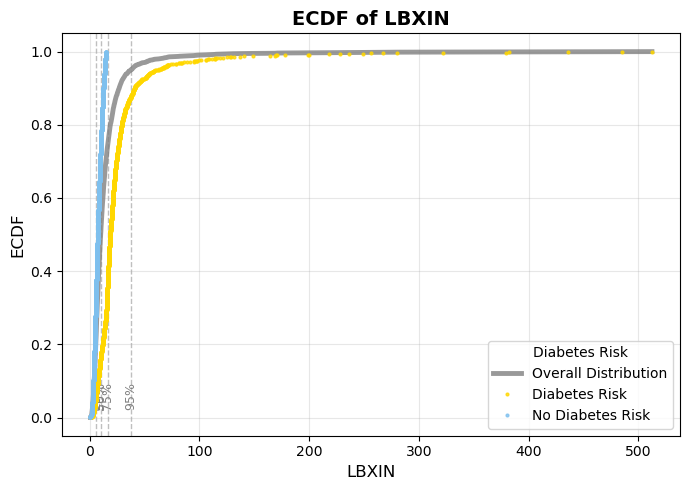


Quantiles for LBXIN:
   25th percentile: 6.17
   50th percentile: 10.01
   75th percentile: 16.56
   95th percentile: 37.64


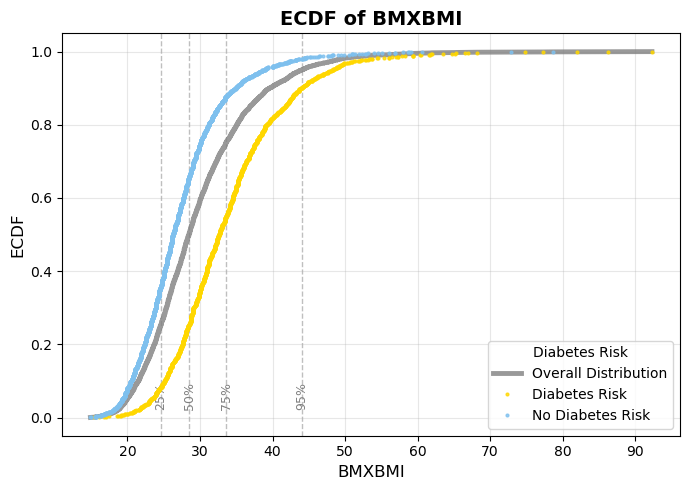


Quantiles for BMXBMI:
   25th percentile: 24.60
   50th percentile: 28.50
   75th percentile: 33.60
   95th percentile: 44.06


In [16]:
def plot_ecdf_combined(data, column, group_col='diabetes_risk', quantiles=[0.25, 0.5, 0.75, 0.95]):
    """
    Plot combined ECDF:
    - Thick overall ECDF in gray (background) with quantile lines
    - Thin group ECDFs (by diabetes_risk) in color

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset containing the variable and the group column.
    column : str
        The name of the numeric variable to plot.
    group_col : str, default='diabetes_risk'
        The grouping column (categorical).
    quantiles : list of float, optional
        Quantile values to annotate on the overall ECDF (0–1 range).
    """

    plt.figure(figsize=(7, 5))

    # --- Overall ECDF ---
    x_all = np.sort(data[column].dropna())
    y_all = np.arange(1, len(x_all) + 1) / len(x_all)
    plt.plot(
        x_all, y_all, color='gray', alpha=0.8, linewidth=3.5,
        label='Overall Distribution', zorder=2
    )

    # --- Quantile lines for reference ---
    q_values = np.quantile(x_all, quantiles)
    for q, val in zip(quantiles, q_values):
        plt.axvline(val, color='gray', linestyle='--', alpha=0.5, linewidth=1.0, zorder=1)
        plt.text(
            val, 0.02, f'{int(q*100)}%', rotation=90,
            color='gray', fontsize=9, va='bottom', ha='center'
        )

    # --- Grouped ECDFs (thin lines) ---
    colors = {'Diabetes Risk': '#FFD700', 'No Diabetes Risk': '#7EC0EE', 'Missing Data': '#CCCCCC'}
    for group, color in colors.items():
        subset = data.loc[data[group_col] == group, column].dropna()
        if len(subset) == 0:
            continue
        x = np.sort(subset)
        y = np.arange(1, len(x) + 1) / len(x)
        plt.plot(
            x, y, marker='.', linestyle='none',
            color=color, alpha=0.8, markersize=4, label=group, zorder=3
        )

    # --- Labels and formatting ---
    plt.xlabel(column.replace('_', ' '), fontsize=12)
    plt.ylabel('ECDF', fontsize=12)
    plt.title(f"ECDF of {column}", fontsize=14, weight='bold')
    plt.legend(title=group_col.replace('_', ' ').title())
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Print quantile summary ---
    print(f"\nQuantiles for {column}:")
    for q, val in zip(quantiles, q_values):
        print(f"  {int(q*100):>3d}th percentile: {val:.2f}")

plot_ecdf_combined(data, 'LBXGLU')
plot_ecdf_combined(data, 'LBXIN')
plot_ecdf_combined(data, 'BMXBMI')

<Axes: xlabel='BMXBMI', ylabel='LBXGLU'>

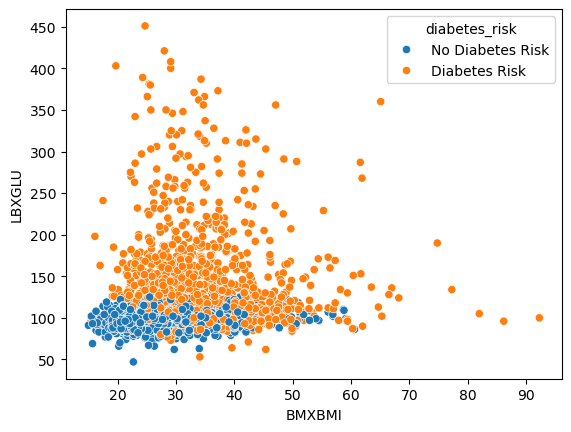

In [17]:
sns.scatterplot(x='BMXBMI', y='LBXGLU', hue='diabetes_risk', data=data)

<Axes: >

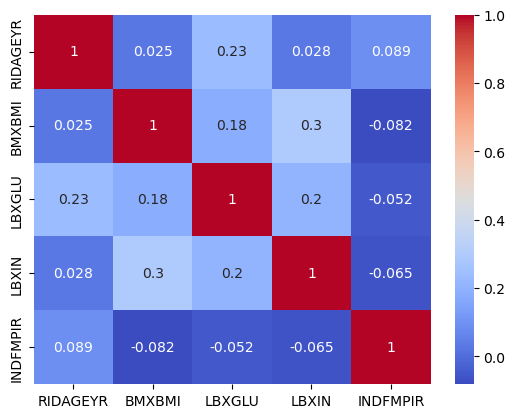

In [18]:
numeric_cols = ['RIDAGEYR', 'BMXBMI', 'LBXGLU', 'LBXIN', 'INDFMPIR']
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')

In [20]:
data['BMI_cat'] = pd.cut(data['BMXBMI'], bins=[0,25,30,100], labels=['Normal','Overweight','Obese'])
data['GLU_cat'] = pd.cut(data['LBXGLU'], bins=[0,100,126,1000], labels=['Normal','Prediabetic','Diabetic'])
pd.crosstab(data['BMI_cat'], data['diabetes_risk'], normalize='index')

diabetes_risk,No Diabetes Risk,Diabetes Risk
BMI_cat,,
Normal,0.867550,0.132450
Overweight,0.693420,0.306580
Obese,0.380763,0.619237
